# 02 – Preprocessing

This notebook cleans the annotation issues found in `01_EDA.ipynb` and prepares a processed YOLO dataset for training.

The raw dataset is not modified. Cleaned images and labels are saved under `data/processed/`.

## 1. Setup

Load the same basic libraries and paths used in the EDA notebook.

In [1]:
from pathlib import Path
import ast
import re
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS = ["train", "valid", "test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

dataset_candidates = [p for p in RAW_DIR.iterdir() if p.is_dir() and all((p / s).exists() for s in SPLITS)]
if dataset_candidates:
    DATASET_DIR = dataset_candidates[0]
else:
    DATASET_DIR = RAW_DIR

DATA_YAML = DATASET_DIR / "data.yaml"

print("Project root:", PROJECT_ROOT)
print("Raw dataset dir:", DATASET_DIR)
print("Processed dataset dir:", PROCESSED_DIR)

Project root: C:\Project\ppe-monitoring-system
Raw dataset dir: C:\Project\ppe-monitoring-system\data\raw\helmet-vest-person.v1-1.yolov11
Processed dataset dir: C:\Project\ppe-monitoring-system\data\processed


In [3]:
yaml_text = DATA_YAML.read_text(encoding="utf-8")
names_match = re.search(r"names:\s*(\[.*\])", yaml_text)
class_names = ast.literal_eval(names_match.group(1)) if names_match else ["Person", "Helmet", "No-Helmet", "Vest", "No-Vest"]
class_map = {i: name for i, name in enumerate(class_names)}

class_map

{0: 'Helmet', 1: 'No-Helmet', 2: 'No-Vest', 3: 'Person', 4: 'Vest'}

## 2. Load Dataset

Load raw images and YOLO labels using the same approach as `01_EDA.ipynb`.

In [4]:
image_rows = []
annotation_rows = []
invalid_label_lines = []

for split in SPLITS:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    image_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        image_rows.append({
            "split": split,
            "image_name": image_path.name,
            "image_path": image_path,
            "label_path": label_path,
            "has_label": label_path.exists(),
        })

        if not label_path.exists():
            continue

        lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
        for line_number, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                invalid_label_lines.append({"split": split, "label_path": label_path, "line_number": line_number, "line": line, "reason": "wrong number of values"})
                continue

            try:
                class_id = int(float(parts[0]))
                x_center, y_center, box_width, box_height = map(float, parts[1:])
            except ValueError:
                invalid_label_lines.append({"split": split, "label_path": label_path, "line_number": line_number, "line": line, "reason": "cannot parse values"})
                continue

            annotation_rows.append({
                "split": split,
                "image_name": image_path.name,
                "image_path": image_path,
                "label_path": label_path,
                "line_number": line_number,
                "class_id": class_id,
                "class_name": class_map.get(class_id, "INVALID"),
                "x_center": x_center,
                "y_center": y_center,
                "box_width": box_width,
                "box_height": box_height,
                "line": line,
            })

images_df = pd.DataFrame(image_rows)
ann_df = pd.DataFrame(annotation_rows)
invalid_lines_df = pd.DataFrame(invalid_label_lines)

print("Images:", len(images_df))
print("Parsed annotations:", len(ann_df))
print("Malformed label lines:", len(invalid_lines_df))

Images: 7390
Parsed annotations: 49413
Malformed label lines: 1


In [5]:
label_rows = []
for split in SPLITS:
    label_dir = DATASET_DIR / split / "labels"
    for label_path in sorted(label_dir.glob("*.txt")):
        image_exists = any((DATASET_DIR / split / "images" / f"{label_path.stem}{ext}").exists() for ext in IMAGE_EXTENSIONS)
        label_rows.append({"split": split, "label_name": label_path.name, "label_path": label_path, "has_image": image_exists, "is_empty": label_path.stat().st_size == 0})

labels_df = pd.DataFrame(label_rows)

ann_df["valid_class_id"] = ann_df["class_id"].between(0, len(class_names) - 1)
ann_df["x1"] = ann_df["x_center"] - ann_df["box_width"] / 2
ann_df["y1"] = ann_df["y_center"] - ann_df["box_height"] / 2
ann_df["x2"] = ann_df["x_center"] + ann_df["box_width"] / 2
ann_df["y2"] = ann_df["y_center"] + ann_df["box_height"] / 2

ann_df["valid_bbox"] = (
    ann_df["x_center"].between(0, 1)
    & ann_df["y_center"].between(0, 1)
    & ann_df["box_width"].between(0, 1)
    & ann_df["box_height"].between(0, 1)
    & (ann_df["box_width"] > 0)
    & (ann_df["box_height"] > 0)
    & (ann_df["x1"] >= 0)
    & (ann_df["x2"] <= 1)
    & (ann_df["y1"] >= 0)
    & (ann_df["y2"] <= 1)
)

raw_quality = pd.Series({
    "empty_label": int(labels_df["is_empty"].sum()),
    "invalid_bbox": int((~ann_df["valid_bbox"]).sum()),
    "malformed_label_lines": len(invalid_lines_df),
    "invalid_class_id": int((~ann_df["valid_class_id"]).sum()),
})

raw_quality

empty_label               41
invalid_bbox             541
malformed_label_lines      1
invalid_class_id           0
dtype: int64

## 3. Inspect Annotation Issues

Inspect the exact problems from EDA before deciding how to clean them.

In [6]:
empty_labels = labels_df[labels_df["is_empty"]].copy()

print("Empty labels by split:")
display(empty_labels.groupby("split").size())
empty_labels.head(10)

Empty labels by split:


split
test      3
train    36
valid     2
dtype: int64

,split,label_name,label_path,has_image,is_empty
1616,train,frame_20250905_153927_246_101_jpg.rf.871a370b4...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1704,train,frame_20250905_154552_246_101_jpg.rf.abf1ad1aa...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1718,train,frame_20250905_154727_249_101_jpg.rf.ff7deb954...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1719,train,frame_20250905_154728_249_101_jpg.rf.3dbf74f23...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1720,train,frame_20250905_154729_249_101_jpg.rf.5fcf447f2...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1728,train,frame_20250905_154912_249_101_jpg.rf.e6e9f5626...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1731,train,frame_20250905_155008_249_101_jpg.rf.516e87002...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1733,train,frame_20250905_155009_249_101_jpg.rf.c9c1f6a2f...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
1735,train,frame_20250905_155010_249_101_jpg.rf.f393b3f9b...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True
2961,train,frame_20250905_161019_249_101_jpg.rf.365702c3b...,C:\Project\ppe-monitoring-system\data\raw\helm...,True,True


Empty label files are valid for YOLO when an image has no target objects. Since the image-label pairing is complete and no corrupted images were found, these files are kept as negative samples.

In [7]:
invalid_bbox_df = ann_df[~ann_df["valid_bbox"]].copy()

invalid_edges = pd.Series({
    "x_center_outside_0_1": int((~invalid_bbox_df["x_center"].between(0, 1)).sum()),
    "y_center_outside_0_1": int((~invalid_bbox_df["y_center"].between(0, 1)).sum()),
    "width_invalid": int(((~invalid_bbox_df["box_width"].between(0, 1)) | (invalid_bbox_df["box_width"] <= 0)).sum()),
    "height_invalid": int(((~invalid_bbox_df["box_height"].between(0, 1)) | (invalid_bbox_df["box_height"] <= 0)).sum()),
    "x1_below_0": int((invalid_bbox_df["x1"] < 0).sum()),
    "x2_above_1": int((invalid_bbox_df["x2"] > 1).sum()),
    "y1_below_0": int((invalid_bbox_df["y1"] < 0).sum()),
    "y2_above_1": int((invalid_bbox_df["y2"] > 1).sum()),
})

invalid_edges

x_center_outside_0_1      0
y_center_outside_0_1      0
width_invalid             0
height_invalid            0
x1_below_0               10
x2_above_1               87
y1_below_0               66
y2_above_1              396
dtype: int64

In [8]:
invalid_bbox_df[["split", "image_name", "class_name", "x_center", "y_center", "box_width", "box_height", "x1", "y1", "x2", "y2"]].head(10)

,split,image_name,class_name,x_center,y_center,box_width,box_height,x1,y1,x2,y2
12473,train,51618130-perfect-team-group-of-six-cheerful-yo...,No-Vest,0.938946,0.622832,0.122115,0.407514,0.877888,0.419075,1.000004,0.826590
13998,train,frame_20250905_153401_249_101_jpg.rf.3959cb9a1...,Person,0.898005,0.728620,0.203995,0.499417,0.796008,0.478912,1.000003,0.978329
14002,train,frame_20250905_153402_249_101_jpg.rf.7c04cf3e3...,Helmet,0.985245,0.526380,0.029516,0.103167,0.970487,0.474796,1.000003,0.577963
14626,train,frame_20250905_153621_246_101_jpg.rf.465b65904...,No-Helmet,0.616586,0.022479,0.039422,0.044965,0.596875,-0.000003,0.636297,0.044962
14650,train,frame_20250905_153625_246_101_jpg.rf.832a5a980...,Helmet,0.420645,0.010437,0.033480,0.020882,0.403904,-0.000003,0.437385,0.020878
14896,train,frame_20250905_153758_246_101_jpg.rf.7fe64e894...,Helmet,0.464262,0.022479,0.034770,0.044965,0.446877,-0.000003,0.481646,0.044962
15336,train,frame_20250905_154512_246_101_jpg.rf.aa0ce3023...,Person,0.333008,0.169701,0.101562,0.339410,0.282227,-0.000003,0.383789,0.339406
15476,train,frame_20250905_155017_246_101_jpg.rf.335d3269f...,Helmet,0.577289,0.020451,0.041293,0.040910,0.556643,-0.000003,0.597936,0.040906
15543,train,frame_20250905_155030_246_101_jpg.rf.177583006...,Helmet,0.590578,0.021319,0.032719,0.042646,0.574219,-0.000003,0.606938,0.042642
15581,train,frame_20250905_155041_246_101_jpg.rf.b69619aff...,Helmet,0.466477,0.021319,0.034512,0.042646,0.449221,-0.000003,0.483732,0.042642


The invalid boxes have valid centers and positive sizes. They only cross the image boundary by a very small amount, usually from rounding. The cleaning rule is to clip box corners to `[0, 1]` and recompute YOLO `x_center y_center width height`.

In [9]:
invalid_lines_df

,split,label_path,line_number,line,reason
0,train,C:\Project\ppe-monitoring-system\data\raw\helm...,1,3 0.5942708333333333 0.25925925925925924 0.595...,wrong number of values


In [10]:
if len(invalid_lines_df):
    line = invalid_lines_df.iloc[0]["line"]
    parts = line.split()
    values = [float(v) for v in parts[1:]]
    xs = values[0::2]
    ys = values[1::2]

    print("Number of values:", len(parts))
    print("Class ID:", parts[0])
    print("Coordinate range:", min(values), "to", max(values))
    print("First 200 characters:")
    print(line[:200])

Number of values: 65
Class ID: 3
Coordinate range: 0.11944444444444445 to 0.6609375
First 200 characters:
3 0.5942708333333333 0.25925925925925924 0.5953125 0.2759259259259259 0.6026041666666667 0.2898148148148148 0.6015625 0.37962962962962965 0.5989583333333334 0.3925925925925926 0.5916666666666667 0.392


The malformed line is polygon-like. To keep preprocessing simple, the image and label file containing this malformed annotation will be removed from the processed dataset.

## 4. Clean Dataset

Save a cleaned copy under `data/processed/` with the same YOLO split structure. Raw files remain unchanged.

In [11]:
EPS = 1e-6


def clip_yolo_box(x_center, y_center, box_width, box_height):
    x1 = np.clip(x_center - box_width / 2, EPS, 1 - EPS)
    y1 = np.clip(y_center - box_height / 2, EPS, 1 - EPS)
    x2 = np.clip(x_center + box_width / 2, EPS, 1 - EPS)
    y2 = np.clip(y_center + box_height / 2, EPS, 1 - EPS)

    new_width = x2 - x1
    new_height = y2 - y1
    new_x_center = x1 + new_width / 2
    new_y_center = y1 + new_height / 2

    return new_x_center, new_y_center, new_width, new_height


In [12]:
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

malformed_label_paths = set(invalid_lines_df["label_path"])

for split in SPLITS:
    (PROCESSED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

cleaning_rows = []

for row in images_df.itertuples(index=False):
    if row.label_path in malformed_label_paths:
        cleaning_rows.append({"label_path": row.label_path, "line_number": None, "action": "removed_malformed_image_label"})
        continue

    processed_image_path = PROCESSED_DIR / row.split / "images" / row.image_path.name
    processed_label_path = PROCESSED_DIR / row.split / "labels" / row.label_path.name

    shutil.copy2(row.image_path, processed_image_path)

    clean_lines = []
    if row.label_path.exists():
        raw_lines = [line.strip() for line in row.label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    else:
        raw_lines = []

    for line_number, line in enumerate(raw_lines, start=1):
        parts = line.split()

        if len(parts) == 5:
            try:
                class_id = int(float(parts[0]))
                x_center, y_center, box_width, box_height = map(float, parts[1:])
            except ValueError:
                cleaning_rows.append({"label_path": row.label_path, "line_number": line_number, "action": "dropped_malformed"})
                continue

            valid_class_id = 0 <= class_id < len(class_names)
            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2
            x2 = x_center + box_width / 2
            y2 = y_center + box_height / 2
            valid_bbox = (
                0 <= x_center <= 1
                and 0 <= y_center <= 1
                and 0 < box_width <= 1
                and 0 < box_height <= 1
                and x1 >= 0
                and y1 >= 0
                and x2 <= 1
                and y2 <= 1
            )

            if not valid_class_id:
                cleaning_rows.append({"label_path": row.label_path, "line_number": line_number, "action": "dropped_invalid_class"})
                continue

            if valid_bbox:
                clean_lines.append(line)
                continue

            if not valid_bbox:
                x_center, y_center, box_width, box_height = clip_yolo_box(x_center, y_center, box_width, box_height)
                if box_width <= 0 or box_height <= 0:
                    cleaning_rows.append({"label_path": row.label_path, "line_number": line_number, "action": "dropped_invalid_bbox"})
                    continue
                cleaning_rows.append({"label_path": row.label_path, "line_number": line_number, "action": "clipped_bbox"})

                clean_lines.append(f"{class_id} {x_center:.8f} {y_center:.8f} {box_width:.8f} {box_height:.8f}")

        else:
            cleaning_rows.append({"label_path": row.label_path, "line_number": line_number, "action": "dropped_malformed"})
            continue

    processed_label_path.write_text("\n".join(clean_lines) + ("\n" if clean_lines else ""), encoding="utf-8")

cleaning_df = pd.DataFrame(cleaning_rows)
cleaning_df["action"].value_counts()

action
clipped_bbox                     541
removed_malformed_image_label      1
Name: count, dtype: int64

In [13]:
processed_yaml = "\n".join([
    "train: train/images",
    "val: valid/images",
    "test: test/images",
    "",
    f"nc: {len(class_names)}",
    f"names: {class_names}",
    "",
])

(PROCESSED_DIR / "data.yaml").write_text(processed_yaml, encoding="utf-8")
print(PROCESSED_DIR / "data.yaml")

C:\Project\ppe-monitoring-system\data\processed\data.yaml


## 5. Check the Processed Dataset

Reload the processed dataset and confirm that image-label pairing and annotations are valid.

In [14]:
processed_image_rows = []
processed_annotation_rows = []
processed_invalid_lines = []

for split in SPLITS:
    image_dir = PROCESSED_DIR / split / "images"
    label_dir = PROCESSED_DIR / split / "labels"
    image_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        processed_image_rows.append({"split": split, "image_name": image_path.name, "image_path": image_path, "label_path": label_path, "has_label": label_path.exists()})

        if not label_path.exists():
            continue

        lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
        for line_number, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                processed_invalid_lines.append({"split": split, "label_path": label_path, "line_number": line_number, "line": line})
                continue

            class_id = int(float(parts[0]))
            x_center, y_center, box_width, box_height = map(float, parts[1:])
            processed_annotation_rows.append({
                "split": split,
                "image_name": image_path.name,
                "image_path": image_path,
                "label_path": label_path,
                "line_number": line_number,
                "class_id": class_id,
                "class_name": class_map.get(class_id, "INVALID"),
                "x_center": x_center,
                "y_center": y_center,
                "box_width": box_width,
                "box_height": box_height,
            })

processed_images_df = pd.DataFrame(processed_image_rows)
processed_ann_df = pd.DataFrame(processed_annotation_rows)
processed_invalid_lines_df = pd.DataFrame(processed_invalid_lines)

processed_ann_df["valid_class_id"] = processed_ann_df["class_id"].between(0, len(class_names) - 1)
processed_ann_df["x1"] = processed_ann_df["x_center"] - processed_ann_df["box_width"] / 2
processed_ann_df["y1"] = processed_ann_df["y_center"] - processed_ann_df["box_height"] / 2
processed_ann_df["x2"] = processed_ann_df["x_center"] + processed_ann_df["box_width"] / 2
processed_ann_df["y2"] = processed_ann_df["y_center"] + processed_ann_df["box_height"] / 2
processed_ann_df["valid_bbox"] = (
    processed_ann_df["x_center"].between(0, 1)
    & processed_ann_df["y_center"].between(0, 1)
    & processed_ann_df["box_width"].between(0, 1)
    & processed_ann_df["box_height"].between(0, 1)
    & (processed_ann_df["box_width"] > 0)
    & (processed_ann_df["box_height"] > 0)
    & (processed_ann_df["x1"] >= 0)
    & (processed_ann_df["x2"] <= 1)
    & (processed_ann_df["y1"] >= 0)
    & (processed_ann_df["y2"] <= 1)
)

processed_labels_df = pd.DataFrame([
    {"split": split, "label_name": p.name, "label_path": p, "is_empty": p.stat().st_size == 0}
    for split in SPLITS
    for p in sorted((PROCESSED_DIR / split / "labels").glob("*.txt"))
])

processed_quality = pd.Series({
    "missing_label": int((~processed_images_df["has_label"]).sum()),
    "empty_label": int(processed_labels_df["is_empty"].sum()),
    "invalid_class_id": int((~processed_ann_df["valid_class_id"]).sum()),
    "invalid_bbox": int((~processed_ann_df["valid_bbox"]).sum()),
    "malformed_label_lines": len(processed_invalid_lines_df),
})

processed_quality

missing_label             0
empty_label              41
invalid_class_id          0
invalid_bbox              0
malformed_label_lines     0
dtype: int64

In [15]:
before_after = pd.DataFrame({
    "raw": pd.Series({
        "images": len(images_df),
        "annotations": len(ann_df),
        "empty_label": int(labels_df["is_empty"].sum()),
        "invalid_bbox": int((~ann_df["valid_bbox"]).sum()),
        "malformed_label_lines": len(invalid_lines_df),
    }),
    "processed": pd.Series({
        "images": len(processed_images_df),
        "annotations": len(processed_ann_df),
        "empty_label": int(processed_labels_df["is_empty"].sum()),
        "invalid_bbox": int((~processed_ann_df["valid_bbox"]).sum()),
        "malformed_label_lines": len(processed_invalid_lines_df),
    }),
}).astype(int)

before_after

,raw,processed
images,7390,7389
annotations,49413,49405
empty_label,41,41
invalid_bbox,541,0
malformed_label_lines,1,0


## 6. Visual Check

Display a few processed images with bounding boxes, using the same visualization style as the EDA notebook.

In [16]:
def draw_yolo_boxes(ax, image_path, labels):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    ax.imshow(image)
    ax.axis("off")

    for label in labels.itertuples(index=False):
        x1 = (label.x_center - label.box_width / 2) * width
        y1 = (label.y_center - label.box_height / 2) * height
        box_w = label.box_width * width
        box_h = label.box_height * height

        rect = plt.Rectangle((x1, y1), box_w, box_h, fill=False, linewidth=2, edgecolor="lime")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 4, 0), label.class_name, color="black", fontsize=7, backgroundcolor="red")

    ax.set_title(f"{image_path.parent.parent.name}/{image_path.name[:35]}", fontsize=9)

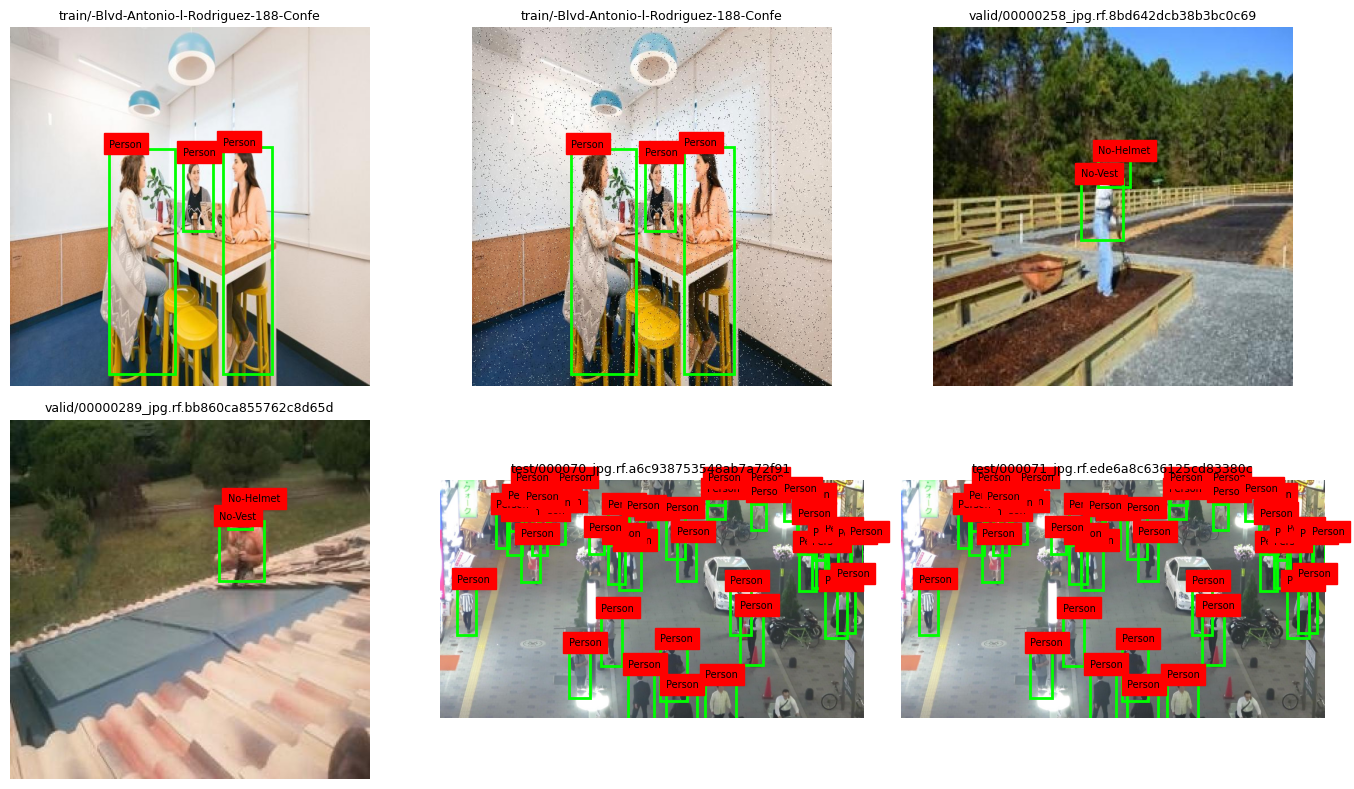

In [17]:
valid_processed_ann_df = processed_ann_df[processed_ann_df["valid_bbox"] & processed_ann_df["valid_class_id"]].copy()

sample_images = []
for split in SPLITS:
    split_images = valid_processed_ann_df[valid_processed_ann_df["split"] == split]["image_path"].drop_duplicates().head(2).tolist()
    sample_images.extend(split_images)

sample_images = sample_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, image_path in zip(axes, sample_images):
    labels = valid_processed_ann_df[valid_processed_ann_df["image_path"] == image_path]
    draw_yolo_boxes(ax, image_path, labels)

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Preprocessing Conclusion

- The raw dataset had **41 empty label files**, **541 invalid bounding boxes**, and **1 malformed label line**.
- Empty label files were kept as negative samples because YOLO supports images without objects.
- The invalid bounding boxes were clipped to the image boundary and rewritten in YOLO format.
- The image and label file containing the malformed polygon-like line were removed from the processed dataset.
- The cleaned dataset was saved to `data/processed/` with `train`, `valid`, and `test` image/label folders.
- The processed dataset has matching images and labels, valid class IDs, valid bounding boxes, and no malformed label lines.
- The processed dataset is ready for YOLO training.